# Value Functions and Breakpoints

Utility-based MCDA methods like UTA and ASSESS aggregate criteria through *value functions* (UTA calls them utility functions) — piecewise-linear mappings from a normalized criterion value in the range [0, 1] to a utility in [0, 1]. A value function is defined by a sequence of points *(x, y)* that control the shape of the mapping. We will refer to these points as *breakpoints*. This notebook walks through the `mcda_vista.value_functions` module: how to generate breakpoints with different shapes, evaluate utilities, and feed them into VISTA.

In [1]:
%matplotlib inline

In [2]:
from mcda_vista.value_functions import (
    generate_breakpoints,
    generate_breakpoints_gain,
    generate_values_from_01,
    verify_breakpoints,
    utility_of_value,
    weighted_utility_of_value,
    Breakpoints,
)
from mcda_vista import generate_vista, plot_vista, plot_vista_comparison
import numpy as np
import matplotlib.pyplot as plt

## 1. What Are Value Functions?

A *value function* (or *utility function*) maps a normalized criterion score $x \in [0, 1]$ to a utility $u(x) \in [0, 1]$. The mapping is piecewise-linear: you specify $K$ breakpoints $(x_1, y_1), \dots, (x_K, y_K)$ with $x_1 = 0$, $x_K = 1$, and the function interpolates linearly between consecutive points.

The *shape* of the value function matters because it encodes the decision-maker's preference structure:

- **Linear** — equal marginal utility everywhere.
- **Convex** (slow start) — small improvements at the low end are valued less; big gains matter more at the top.
- **Concave** (fast start) — initial improvements are highly valued; diminishing returns at the top.
- **Sigmoid** — an S-shaped curve that combines both effects.
- **Power** — controlled by an exponent $p$; convex for $p > 1$, concave for $p < 1$.

## 2. Generating Breakpoint Shapes

`generate_values_from_01(K, form)` produces $k$ values in [0, 1] according to a shape descriptor. Let's visualize all available shapes.

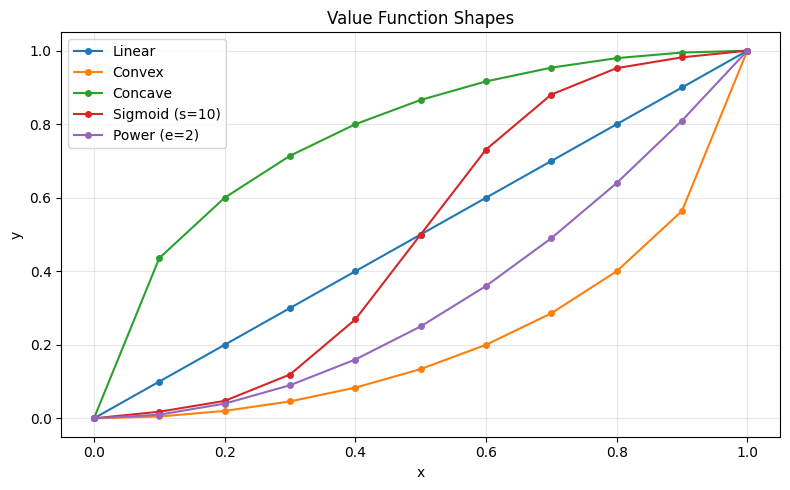

In [7]:
k = 11  # 11 breakpoints

forms = [("L",), ("X",), ("V",), ("S", 10), ("P", 2)]
labels = ["Linear", "Convex", "Concave", "Sigmoid (s=10)", "Power (e=2)"]

fig, ax = plt.subplots(figsize=(8, 5))
x_vals = np.linspace(0, 1, k)

for form, label in zip(forms, labels):
    y_vals = generate_values_from_01(k, form)
    ax.plot(x_vals, y_vals, marker="o", markersize=4, label=label)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Value Function Shapes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

All shapes start at 0 and end at 1, but the path they take between those endpoints is very different — and that path determines how the MCDA method trades off criterion values.

## 3. Building Breakpoints (Gain vs Cost)

`generate_breakpoints(mode, K, formX, formY)` assembles full breakpoint sequences. The `mode` parameter controls orientation:

- **gain** — higher criterion values yield higher utility (benefit criterion).
- **cost** — lower criterion values yield higher utility; the y-values are mirrored ($y \to 1 - y$).

In [4]:
# Cost mode applies y -> 1-y inversion, which can break monotonicity
# for some shapes (e.g. convex "X").  Use linear "L" for a safe demo,
# then build the cost mirror manually to show the concept.
bpts_gain = generate_breakpoints("gain", 6, ("L",), ("L",))
bpts_cost = [(x, 1.0 - y) for x, y in bpts_gain]

print("Gain breakpoints (formY=L):")
for x, y in bpts_gain:
    print(f"  x={x:.3f}  y={y:.3f}")

print("\nCost breakpoints (y -> 1-y):")
for x, y in bpts_cost:
    print(f"  x={x:.3f}  y={y:.3f}")

Gain breakpoints (formY=L):
  x=0.000  y=0.000
  x=0.200  y=0.200
  x=0.400  y=0.400
  x=0.600  y=0.600
  x=0.800  y=0.800
  x=1.000  y=1.000

Cost breakpoints (y -> 1-y):
  x=0.000  y=1.000
  x=0.200  y=0.800
  x=0.400  y=0.600
  x=0.600  y=0.400
  x=0.800  y=0.200
  x=1.000  y=0.000


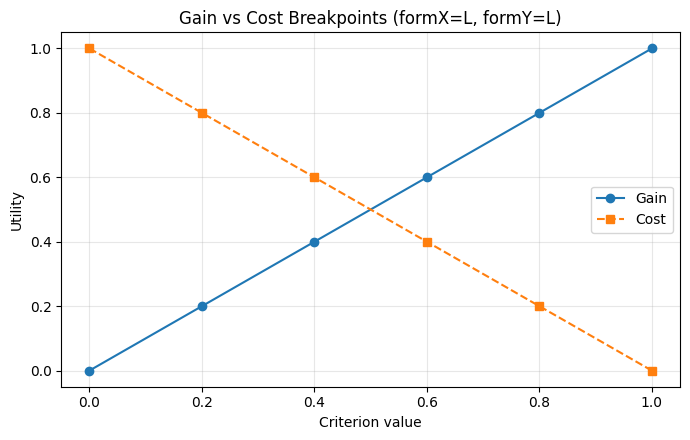

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

gx, gy = zip(*bpts_gain)
cx, cy = zip(*bpts_cost)

ax.plot(gx, gy, "o-", label="Gain", markersize=6)
ax.plot(cx, cy, "s--", label="Cost", markersize=6)

ax.set_xlabel("Criterion value")
ax.set_ylabel("Utility")
ax.set_title("Gain vs Cost Breakpoints (formX=L, formY=L)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The cost curve mirrors the gain curve: where the gain function gives low utility, the cost function gives high utility, and vice versa. You can also use `generate_breakpoints_gain()` as a shorthand for the gain-only case.

## 4. Evaluating Utilities

Given a set of breakpoints and a criterion value, `utility_of_value()` performs piecewise-linear interpolation. `weighted_utility_of_value()` multiplies the result by a weight.

In [3]:
bpts = generate_breakpoints("gain", 6, ("L",), ("X",))

val = 0.3
u = utility_of_value(val, bpts)
wu = weighted_utility_of_value(val, 0.5, bpts)

print(f"utility_of_value({val}, bpts)         = {u:.4f}")
print(f"weighted_utility_of_value({val}, 0.5, bpts) = {wu:.4f}")
print(f"  (expected: 0.5 × {u:.4f} = {0.5 * u:.4f})")

utility_of_value(0.3, bpts)         = 0.0518
weighted_utility_of_value(0.3, 0.5, bpts) = 0.0259
  (expected: 0.5 × 0.0518 = 0.0259)


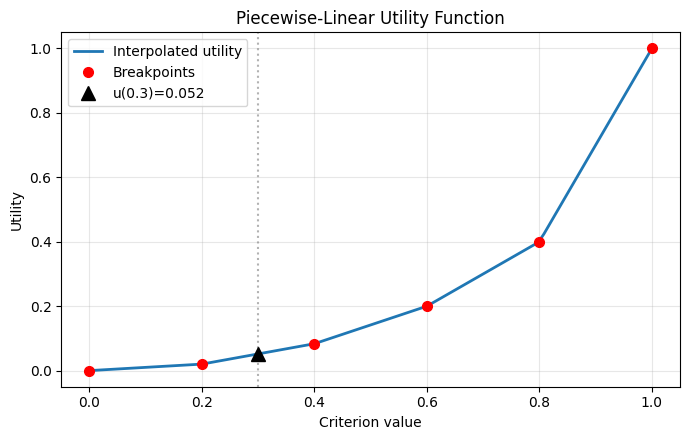

In [4]:
# Full utility curve — evaluate at 100 evenly spaced points
xs = np.linspace(0, 1, 100)
ys = [utility_of_value(x, bpts) for x in xs]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xs, ys, linewidth=2, label="Interpolated utility")

# Overlay the breakpoints
bx, by = zip(*bpts)
ax.plot(bx, by, "ro", markersize=7, zorder=5, label="Breakpoints")

# Mark the sample point
ax.axvline(val, color="grey", linestyle=":", alpha=0.6)
ax.plot(val, u, "k^", markersize=10, zorder=5, label=f"u({val})={u:.3f}")

ax.set_xlabel("Criterion value")
ax.set_ylabel("Utility")
ax.set_title("Piecewise-Linear Utility Function")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. UTA with Different Value Function Shapes

The UTA method builds an additive utility model from breakpoints. By changing the `form` parameter, we alter the shape of each criterion's value function, which can substantially affect the vista.

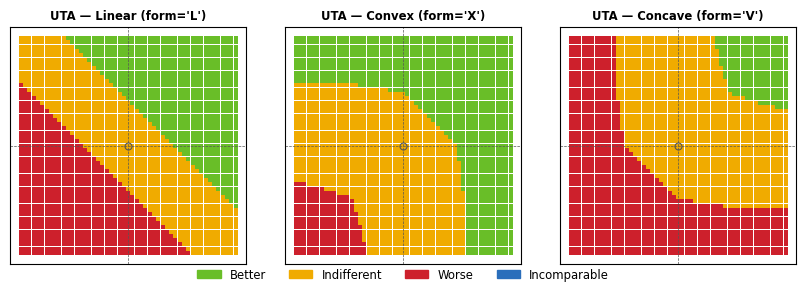

In [6]:
forms_uta = ["L", "X", "V"]
form_labels = ["Linear", "Convex", "Concave"]

results_form = []
for form, label in zip(forms_uta, form_labels):
    r = generate_vista("uta", resolution=51, k=5, form=form, delta=0.10, progress=False)
    r.method_name = f"UTA — {label} (form={form!r})"
    results_form.append(r)

fig = plot_vista_comparison(results_form, ncols=3, point_size=7)

The linear `form` treats all criterion values equally. The convex `form` penalizes low values less, while the concave `form` rewards low values more. These are the same geometric shapes we plotted earlier, but now applied inside a full ranking method evaluation.

## 6. Effect of Number of Breakpoints (*k*)

More breakpoints give the value function greater flexibility to deviate from a straight line. With $k = 3$ (minimum meaningful count) the curve is essentially a single hinge; as $k$ grows the piecewise-linear approximation becomes smoother.

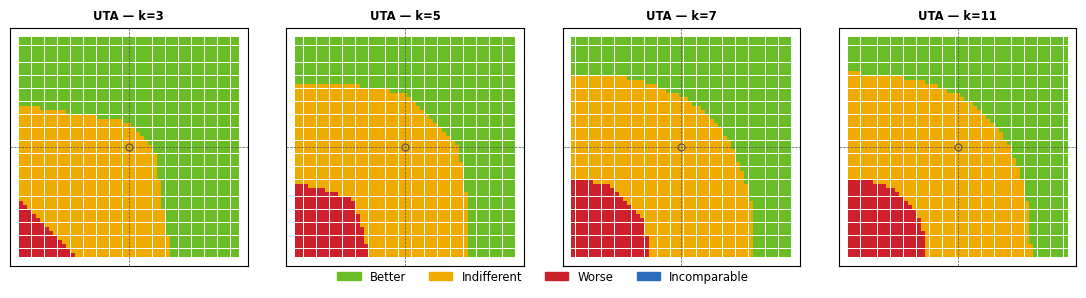

In [8]:
k_values = [3, 5, 7, 11]

results_k = []
for k in k_values:
    r = generate_vista("uta", resolution=51, k=k, form="X", delta=0.10, progress=False)
    r.method_name = f"UTA — k={k}"
    results_k.append(r)

fig = plot_vista_comparison(results_k, ncols=4, point_size=5)

With a convex form (`X`), increasing *k* produces an increasingly smooth convex curve. The vistas converge as the piecewise-linear approximation approaches the true circular arc.

## 7. UTA vs ASSESS

Both UTA and ASSESS use value functions defined by breakpoints, but they aggregate criterion utilities differently:

- UTA uses an *additive* model: $U(a) = \sum_{j} w_j \, u_j(a_j)$
- ASSESS uses a *multiplicative* (Keeney–Raiffa) model: $U(a) = \prod_{j} \bigl(1 + k_j \, u_j(a_j)\bigr)$

The multiplicative form introduces interaction between criteria — a low score on one criterion cannot be fully compensated by a high score on another.

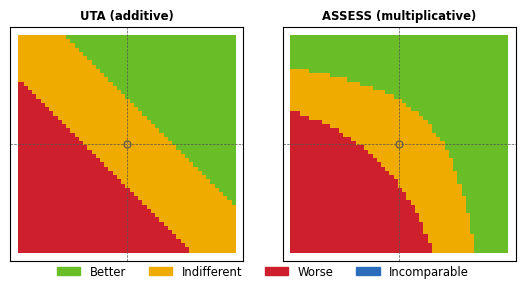

In [16]:
result_uta = generate_vista("uta", resolution=51, k=5, form="L", delta=0.10, progress=False)
result_uta.method_name = "UTA (additive)"

result_assess = generate_vista("assess", resolution=51, k=5, form="L", delta=0.10, progress=False)
result_assess.method_name = "ASSESS (multiplicative)"

fig = plot_vista_comparison([result_uta, result_assess], ncols=2, point_size=15)

With identical settings (linear form, $k = 5$, $\delta = 0.10$), the two methods can still produce noticeably different vistas because of the underlying aggregation rule. The multiplicative ASSESS model often yields a wider indifference region near the reference point.